In [1]:
import pandas as pd
import numpy as np
import math
import matplotlib.pyplot as plt
import scipy.optimize as op
from random import randrange

### 1. Tipos de variables
- Variables númericas : magnitude, depth, cdi, mmi y sig
- Variables categóricas : alert
- Clases en alert : green, yellow, orange y red


In [2]:
#File carga el conjunto de datos earthquake_alert_balanced_dataset.csv
file = pd.read_csv('earthquake_alert_balanced_dataset.csv')
#Definición de X, matriz de características(variables independientes)
X = pd.DataFrame({'magnitude': file['magnitude'],'depth': file['depth'],'cdi': file['cdi'],'mmi': file['mmi'], 'sig': file['sig']})
#Definición de y, vector objetivo compuesto por 4 clases(variable dependiente)
y = pd.DataFrame({'alert': file['alert']})

### 1.1 Estudio de la existencia de valores perdidos

In [3]:
print("El tamaño de X es: ", X.shape)
print("La longitud del vector y es: ", len(y))
print("valores nulos por columna:")
#Se comprueba que no existen datos nulos en el dataset, en este caso los valores nulos por columna son 0, 
#así que no es necesario la sustitución de datos 
print(file.isnull().sum())

El tamaño de X es:  (1300, 5)
La longitud del vector y es:  1300
valores nulos por columna:
magnitude    0
depth        0
cdi          0
mmi          0
sig          0
alert        0
dtype: int64


In [4]:
#Visualización de los datos
display(file.head()) 

,magnitude,depth,cdi,mmi,sig,alert
0,7.0,14.0,8.0,7.0,0.0,green
1,6.9,25.0,4.0,4.0,-33.0,green
2,7.0,579.0,3.0,3.0,-13.0,green
3,7.3,37.0,5.0,5.0,65.0,green
4,6.6,624.0,0.0,2.0,-98.0,green


### 1.2 Estandarización de los datos

In [5]:
# featureNormalize normaliza las características (features) en X y devuelve una versión normalizada de X donde
# el valor medio de cada característica(mu) es 0 y la desviación estándar(sigma) es 1.
def featureNormalize(X):
    X_norm = X
    X_norm = ((X - X.mean())/(X.std()))
    mu = X.mean()
    sigma = X.std()

    return X_norm, mu, sigma

### 1.3 Visualización de los datos

In [6]:
#Función plotData: Visualización de dos características(d1, d2) para analizar la distribución de las distintas clases
def plotData(X, y, d1, d2):
    #Separación de las diferentes clases de y
    green = X[y['alert'] == 'green']
    yellow = X[y['alert'] == 'yellow']
    orange = X[y['alert'] == 'orange']
    red = X[y['alert'] == 'red']

    # Gráfico de dispersión. Se pinta cada clase de un su color correspodiente
    plt.figure(figsize=(6,4))
    plt.scatter(green[d1], green[d2], color='green', label='Green', marker='o')
    plt.scatter(yellow[d1], yellow[d2], color='yellow', label='Yellow', marker='o')
    plt.scatter(orange[d1], orange[d2], color='orange', label='Orange', marker='o')
    plt.scatter(red[d1], red[d2], color='red', label='Red', marker='o')

    plt.xlabel(d1)
    plt.ylabel(d2)
    plt.legend()
    plt.grid(True)
    plt.show()

In [7]:
def plotDecisionBoundary(X, y, theta, label_x, label_y):
    green = X[y['alert'] == 'green']
    yellow = X[y['alert'] == 'yellow']
    orange = X[y['alert'] == 'orange']
    red = X[y['alert'] == 'red']
    
    plt.scatter(green[label_x], green[label_y], color='green', label='Green')
    plt.scatter(yellow[label_x], yellow[label_y], color='yellow', label='Yellow')
    plt.scatter(orange[label_x], orange[label_y], color='orange', label='Orange')
    plt.scatter(red[label_x], red[label_y], color='red', label='Red')
    
    plt.xlabel(label_x)
    plt.ylabel(label_y)
    x_values = np.linspace(min(X[label_x]), max(X[label_x]))
    y_values = - (theta[0] + theta[1] * x_values) / theta[2]
    
    plt.plot(x_values, y_values, label="Decision boundary")
    plt.legend()
    plt.show()

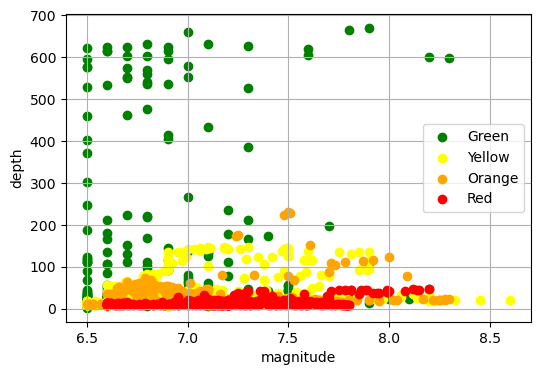

In [8]:
plotData(X, y, 'magnitude', 'depth')

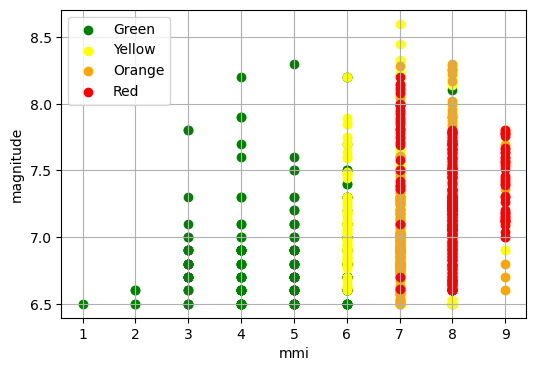

In [9]:
plotData(X, y, 'mmi', 'magnitude')

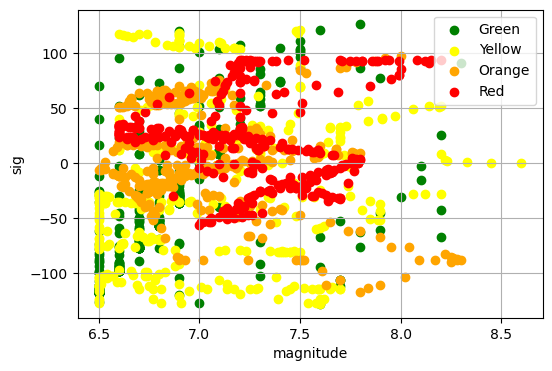

In [10]:
plotData(X, y, 'magnitude', 'sig')

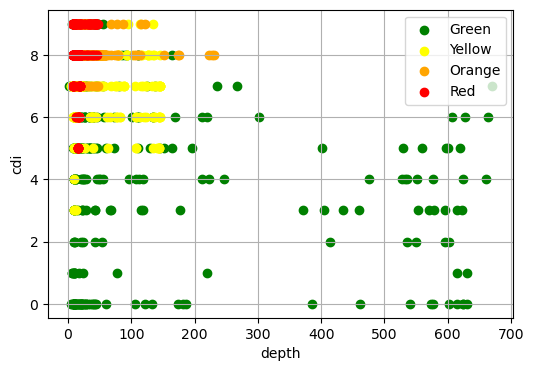

In [11]:
plotData(X, y, 'depth', 'cdi')

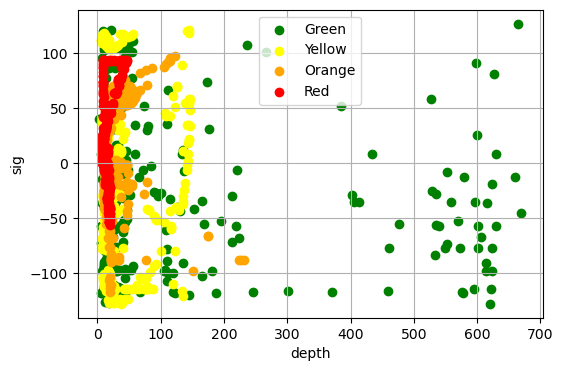

In [12]:
plotData(X, y, 'depth', 'sig')

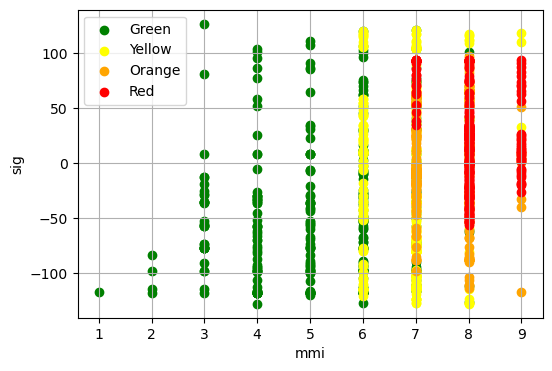

In [13]:
plotData(X, y, 'mmi', 'sig')

### 2. Implementación del modelo de Regresión Logística


In [14]:
#Función sigmoide: transforma cualquier valor real en un valor entre 0 y 1. 
#Es fundamental para entrenar el modelo y calcular el coste.
def sigmoid(z):
    g = 1 / (1+np.exp(-z)) #Cálculo de la sigmoide
    return g

In [15]:
#Función coste: Calcula el error entre el valor real y el valor aproximado por el modelo
def costFunction(theta, X, y):
    m = len(y) # Número de ejemplos de entrenamiento
    J = 0 # Inicialización del coste (J)
    
    # h (Hipótesis): Es la predicción del modelo. Aplica la función sigmoide para mantener los datos entre 0 y 1.
    h = sigmoid(np.dot(X, theta))
    J = -(1 / m) * np.sum(np.multiply(y, np.log(h)) + np.multiply(1 - y, np.log(1 - h)), axis=0) #Cálculo del coste vectorizado  
    return J

##### La minimización de la función de coste se realiza optimizando los pesos $\theta$. La Función Gradiente es fundamental en este proceso, 
##### ya que provee al algoritmo de optimización (fmin_cg) el vector de derivadas parciales necesario para determinar la dirección de búsqueda 
##### y actualizar los parámetros eficientemente hasta lograr la convergencia del modelo.

In [16]:
#Función gradiente 
def gradientFunction(theta, X, y):
    m = len(y) # Número de ejemplos de entrenamiento
    # h (Hipótesis): Es la predicción del modelo. Aplica la función sigmoide para mantener los datos entre 0 y 1.
    h = sigmoid(np.dot(X, theta))
    # Cálculo vectorizado del gradiente
    grad = (1/m) * (np.dot(X.T, (h - y)))
    return grad

### Función que transforma la salida para problemas de Clasificación multiclase(OneVsAll)
La función recibe como parámetros: la salida ($y$) y el valor de la clase actual (de 1 a 4 este caso). La salida de la función tendrá tantas filas como tuviese $y$ con valor 1 cuando la clase que se pasa por parámetro coincida con el valor de $y$ en esa fila y con 0 en caso contrario.

In [17]:
def y_change(y, cl):
    y_pr=[] # Lista para almacenar valores binarios
    #Bucle for: Recorre todo y, si y es igual al parámetro pasado(cl) guarda en y_pr el valor 1 y 0 en caso contrario
    for i in range(0, len(y)): 
        if y['alert'][i] == cl:
            y_pr.append(1)
        else:
            y_pr.append(0) 
    #Convertir y_pr en DataFrame para mantener la consistencia del código
    y_new = pd.DataFrame({'label':y_pr})
    return y_new

In [18]:
#Función costePorClase: Calcula el coste de cada clase por separado en cada iteración del optimizador (fmin_cg) y lo guarda. 
#Es fundamental para mostrar la convergencia de cada clase.
def costePorClase(theta, X, y, history_list):
    c = costFunction(theta, X, y) #Calcula el coste
    history_list.append(c) #Guarda el coste en history_list para visualizarlo después

### Función para entrenar problemas de clasificación multiclase
La función training se encarga de realizar el entrenamiento del método. Para ello, esta función recibirá el número de clases, los parámetros theta iniciales y el conjunto de entrenamiento (X_train,y_train), 
y devolverá los parámetros theta que definen el modelo aprendido. Las dimensiones de estos son num_class x (n+1), donde n es el número de atributos de la matriz X.

fmin_cg es una función de optimización que sirve para encontrar los mejores parámetros Theta ($\theta$) ya que es más eficiente computacionalmente y ajusta automáticamente la tasa de aprendizaje (learning rate), evitando la selección manual de alpha.

In [19]:
def training(initial_theta, X_train, y_train, num_clases):
  all_theta = [] # Lista vacía para incluir las theta óptimas de cada clase
  all_cost = [] # Lista vacía para incluir el coste final de cada clase
  all_class = [] # Lista vacía para añadir las clases
  all_history = [] #Lista vacía para guardar el coste de cada clase
  alert_list = ['green', 'yellow', 'orange', 'red'] #Lista con el nombre de cada clase
    
  #Bucle for para aplicar el algoritmo de optimización a cada clase
  for current_class in range(num_clases): 
      clase_actual = alert_list[current_class]
      cost_history_class = [] #Lista temporal para el historial de coste esta iteración
      y_bin = y_change(y_train, clase_actual).to_numpy().flatten() # Transforma la clase actual en '1' y el resto en '0'.
      
      res_optimization = op.fmin_cg(maxiter=1000, f=costFunction, x0=initial_theta.flatten(), fprime=gradientFunction, 
                             args=(X_train, y_bin),
                             callback = lambda t: costePorClase(t, X_train, y_bin, cost_history_class),
                             full_output = True)

      all_theta.append(res_optimization[0]) # Theta óptimos del algoritmo de optimización
      all_cost.append(res_optimization[1]) # Coste del algoritmo de optimización
      all_class.append(current_class) # Clase actual
      all_history.append(cost_history_class) # Historial de convergencia
    
  df_opt = pd.DataFrame({'class':all_class, 'theta':all_theta, 'cost':all_cost, 'history': all_history}) # Creamos dataframe que devolverá la función
  
  return df_opt

#### Función Predict
Calcula la probabilidad de que la alerta pertenezca a cada una de las 4 clases (green, yellow, orange, red) y asigna la etiqueta correspondiente a la clase con la probabilidad más alta.

In [20]:
def predict(res_optimization, X):
  m = len(X)
  all_instances = [] # Lista vacía para incluir las instancias/filas de X
  all_predictions = [] # Lista vacía para incluir las predicciones

  for i in range(len(X)):  # Bucle for que recorre cada fila de X
    all_h = [] # Lista vacía para añadir las h de la fila i (tamaño de all_h: num_classes en este caso 4)
  
    for current_class in res_optimization['class']: # bucle para los theta óptimos de cada clase
      h = sigmoid(np.dot(res_optimization['theta'][current_class], X.iloc[i,:].values)) # Calcula la probabilidad (Sigmoide) del tipo de alerta para el terremoto
      all_h.append(h)  # Añado cada h a la lista all_h
    
    pred = np.argmax(all_h) #La función argmax devuelve el índice de la mejor predicción
    all_predictions.append(pred) # Añado la mejor a la lista de predicciones finales
    all_instances.append(i) # Añado la instancia/fila a la lista
  
  return pd.DataFrame({'instance':all_instances, 'prediction':all_predictions})


### Evaluación usando Hold Out
Para Regresión Logística se ha seleccionado la estrategia de evaluación Hold-out ya que el conjunto de datos se encuentra balanceado, lo que garantiza que una división aleatoria simple mantenga la representatividad de las clases en ambos subconjuntos. Además, permite generar un gráfico de convergencia único y limpio con menos coste computacional. 

In [21]:
def holdout(X, y, percentage=0.6):
  X_training = X.sample(frac=percentage, random_state=42) # Selecciona aleatoriamente el numero de filas indicado para X_training
  y_training = y.iloc[X_training.index] # Selecciona las filas del y_training
  X_test = X.iloc[~X.index.isin(X_training.index)] # Selecciona las filas que NO están en X_training
  y_test = y.iloc[~X.index.isin(X_training.index)] #Selecciona las filas que NO están en y_training

  print("El tamaño del training debe ser: ", round(percentage*len(X)), " - Comprobación: tamaño X_training es ", len(X_training), " y tamaño y_training es", len(y_training))
  print("El tamaño del test debe ser: ", len(X)-round(percentage*len(X)), " - Comprobación: tamaño X_test es ", len(X_test), " y tamaño y_test es", len(y_test))

  # Reseteamos los índices de todos los conjuntos
  X_training = X_training.reset_index(drop=True)
  y_training = y_training.reset_index(drop=True)
  X_test = X_test.reset_index(drop=True)
  y_test = y_test.reset_index(drop=True)
  
  return X_training, y_training, X_test, y_test

#### Matriz de confusión
Función que sirve para analizar donde comete errores el modelo. A la función se le pasa el número de clases y el resultado del entrenamiento y predicción. La matriz tiene dimensión 4x4 (num_classes x num_classes). En ella, las filas representan las clases reales (valores verdaderos) y las columnas representan las predicciones hechas por el modelo, permitiendo ver en la diagonal principal los aciertos y fuera de ella las confusiones.

In [22]:
def confusion_matrix(y_train, y_pred, num_classes):
    #Se inicializa a 0 la matriz
    matrix = np.zeros((num_classes, num_classes), dtype=int)

    # zip(): Empareja cada valor real con su predicción correspondiente para iterar a la vez
    # yt: Índice de la clase real (Fila)
    # yp: Índice de la clase predicha (Columna)
    for yt, yp in zip(y_train, y_pred):
        # Si yt == yp, sumamos un 1 en la diagonal principal (Acierto)
        matrix[yt][yp] += 1

    return matrix

### 2.1 Inicialización de los parámetros


In [23]:
m, n = X.shape
initial_theta = np.zeros((n+1, 1))

#HOLDOUT 70-30
X_training, y_training, X_test, y_test = holdout(X, y, 0.7)
#Normalización de los datos de entrenamiento y test antes de añadir la columna de unos para evitar dividir entre 0 y que los valores sean Nan.
X_training_stan, mu, sigma = featureNormalize(X_training)
X_test_stan = (X_test - mu) / sigma

# Se añade una columna de unos a X y al conjunto de entrenamiento y test
X_training_stan.insert(0, 'uno', 1)
X_test_stan.insert(0, 'uno', 1)

El tamaño del training debe ser:  910  - Comprobación: tamaño X_training es  910  y tamaño y_training es 910
El tamaño del test debe ser:  390  - Comprobación: tamaño X_test es  390  y tamaño y_test es 390


#### Realizamos una prueba con la clase 'red' para verificar la convergencia de la clase red con el optimizador antes de ejecutar el bucle principal de entrenamiento.

In [24]:
# y_bin convierte todas las clases a 0 excepto red(OneVsAll)
y_bin = y_change(y_training, 'red')
#Ejecución del algoritmo de optimización para verificar el coste mínimo de la clase red
params_fmin1 = op.fmin_cg(maxiter=400, f=costFunction, x0=initial_theta.flatten(), fprime=gradientFunction,args=(X_training_stan, y_bin.to_numpy().flatten()))

print("\nCoste de theta encontrado por fmin_cg: \n", params_fmin1)
print("\tTheta: ", params_fmin1)

Optimization terminated successfully.
         Current function value: 0.308496
         Iterations: 51
         Function evaluations: 159
         Gradient evaluations: 159

Coste de theta encontrado por fmin_cg: 
 [-4.52780779  0.57237742 -6.45100504 -0.03486536  2.68375912  0.91814252]
	Theta:  [-4.52780779  0.57237742 -6.45100504 -0.03486536  2.68375912  0.91814252]


### 2.1 Fase de entrenamiento

In [25]:
#Inicialización de los parámetros para el modelo de entrenamiento
num_classes = 4
classes_name = ['green', 'yellow', 'orange', 'red']
initial_theta = np.zeros((X_training_stan.shape[1],1))
#Ejecución de la función training
res_optimization_training = training(initial_theta, X_training_stan, y_training, num_classes)

Optimization terminated successfully.
         Current function value: 0.229612
         Iterations: 12
         Function evaluations: 39
         Gradient evaluations: 39
Optimization terminated successfully.
         Current function value: 0.521335
         Iterations: 14
         Function evaluations: 33
         Gradient evaluations: 33
Optimization terminated successfully.
         Current function value: 0.495559
         Iterations: 15
         Function evaluations: 40
         Gradient evaluations: 40
Optimization terminated successfully.
         Current function value: 0.308496
         Iterations: 51
         Function evaluations: 159
         Gradient evaluations: 159


### 2.3 gráfico de convergencia por cada clase

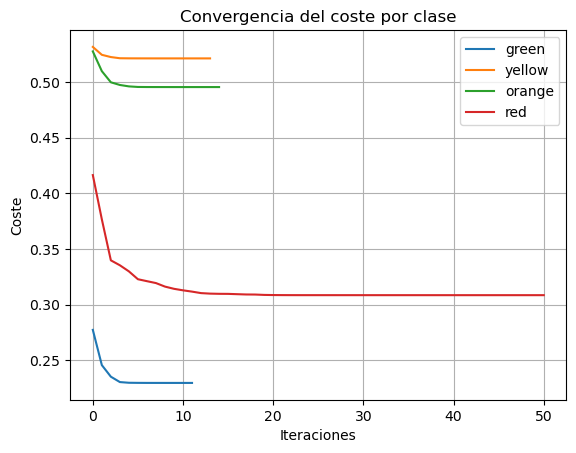

In [26]:
#Bucle for: Pinta el coste con respecto al número de iteraciones de cada clase con los datos guardados en res_optimization_training['history']
for i in range(num_classes):
    clases = res_optimization_training['history'][i]
    plt.plot(clases, label=classes_name[i])


plt.xlabel("Iteraciones")
plt.ylabel("Coste")
plt.title("Convergencia del coste por clase")
plt.legend()
plt.grid(True)
plt.show()

### 2.4 Fase de predicción y métrica de evaluación

In [27]:
# Calcula la predicción de entrenamiento y la guarda en res_prediction_training
res_prediction_training = predict(res_optimization_training, X_training_stan)

In [28]:
#Definición de un diccionario de mapeo para poder comparar las predicciones númericas del modelo
mapping = {'green': 0, 'yellow': 1, 'orange': 2, 'red': 3}
#Calcula la tasa de acierto comparando la predicción del training con el training real(se mapea para que se comparen valores del mismo tipo)
accuracy_training = np.mean(res_prediction_training['prediction'] == y_training['alert'].map(mapping))
print("Training accuracy: ", accuracy_training)

Training accuracy:  0.6747252747252748


In [29]:
#Calcula la predicción de test y la guarda res_prediction_test
res_prediction_test = predict(res_optimization_training, X_test_stan)
#Calcula la tasa de acierto comparando la predicción del test con el test real(se mapea para que se comparen valores del mismo tipo)
accuracy_test = np.mean(res_prediction_test['prediction'] == y_test['alert'].map(mapping)) 
print("Test accuracy: ", accuracy_test)

Test accuracy:  0.6641025641025641


In [30]:
#Matriz de confusión de entrenamiento
matrix_train = confusion_matrix(y_training['alert'].map(mapping), res_prediction_training['prediction'], num_classes)
print(matrix_train)

[[199  19  12   7]
 [ 53  99  36  32]
 [  0  42 134  58]
 [  0   2  35 182]]


In [31]:
#Matriz de confusión de test
matrix_test = confusion_matrix(y_test['alert'].map(mapping), res_prediction_test['prediction'], num_classes)
print(matrix_test)

[[77  6  5  0]
 [29 44 19 13]
 [ 0 18 52 21]
 [ 0  1 19 86]]


### Modificaciones Regresión Logística

##### a. Seleccionar, por pares, al menos cuatro o seis variables independientes del conjunto de datos y entrenar un modelo de regresión logística con dos variables 

#### Inicialización de los parámetros, entrenamiento y cálculo de la tasa de predicción del par de variables magnitude depth

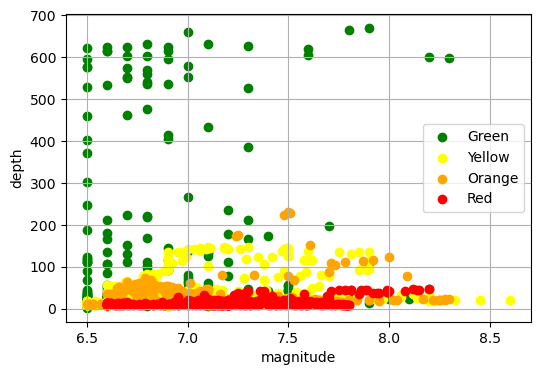

In [32]:
plotData(X, y, 'magnitude', 'depth')

In [33]:
X1 = X[['magnitude','depth']]

#HOLDOUT 70-30
X_training_X1, y_training_X1, X_test_X1, y_test_X1 = holdout(X1, y, 0.7)
#Normalización de los datos de entrenamiento y test antes de añadir la columna de unos para evitar dividir entre 0 y que los valores sean Nan.
X_training_stan_X1, mu_X1, sigma_X1 = featureNormalize(X_training_X1)
X_test_stan_X1 = (X_test_X1 - mu_X1) / sigma_X1

# Se añade una columna de unos al conjunto de entrenamiento y test
X_training_stan_X1.insert(0, 'uno', 1)
X_test_stan_X1.insert(0, 'uno', 1)
initial_theta_X1 = np.zeros((X_training_stan_X1.shape[1],1))

#Ejecución de la función training
res_optimization_training_X1 = training(initial_theta_X1, X_training_stan_X1, y_training_X1, num_classes)
# Calcula la predicción de entrenamiento y la guarda en res_prediction_training_X1
res_prediction_training_X1 = predict(res_optimization_training_X1, X_training_stan_X1)
#Calcula la tasa de acierto comparando la predicción del training con el training real(se mapea para que se comparen valores del mismo tipo)
accuracy_training_X1 = np.mean(res_prediction_training_X1['prediction'] == y_training_X1['alert'].map(mapping))
print("Training accuracy: ", accuracy_training_X1*100)
#Calcula la predicción de test y la guarda res_prediction_test
res_prediction_test_X1 = predict(res_optimization_training_X1, X_test_stan_X1)
#Calcula la tasa de acierto comparando la predicción del test con el test real(se mapea para que se comparen valores del mismo tipo)
accuracy_test_X1 = np.mean(res_prediction_test_X1['prediction'] == y_test_X1['alert'].map(mapping)) 
print("Test accuracy: ", accuracy_test_X1*100)

El tamaño del training debe ser:  910  - Comprobación: tamaño X_training es  910  y tamaño y_training es 910
El tamaño del test debe ser:  390  - Comprobación: tamaño X_test es  390  y tamaño y_test es 390
Optimization terminated successfully.
         Current function value: 0.467030
         Iterations: 8
         Function evaluations: 22
         Gradient evaluations: 22
Optimization terminated successfully.
         Current function value: 0.550398
         Iterations: 7
         Function evaluations: 17
         Gradient evaluations: 17
Optimization terminated successfully.
         Current function value: 0.562427
         Iterations: 6
         Function evaluations: 15
         Gradient evaluations: 15
Optimization terminated successfully.
         Current function value: 0.434106
         Iterations: 24
         Function evaluations: 70
         Gradient evaluations: 70
Training accuracy:  44.83516483516484
Test accuracy:  43.07692307692308


#### Inicialización de los parámetros, entrenamiento y cálculo de la tasa de predicción del par de variables magnitude mmi 

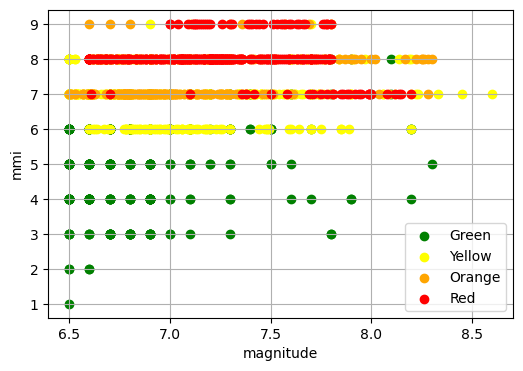

In [34]:
plotData(X, y, 'magnitude', 'mmi')

In [35]:
X2 = X[['magnitude','mmi']]

#HOLDOUT 70-30
X_training_X2, y_training_X2, X_test_X2, y_test_X2 = holdout(X2, y, 0.7)
#Normalización de los datos de entrenamiento y test antes de añadir la columna de unos para evitar dividir entre 0 y que los valores sean Nan.
X_training_stan_X2, mu_X2, sigma_X2 = featureNormalize(X_training_X2)
X_test_stan_X2 = (X_test_X2 - mu_X2) / sigma_X2

# Se añade una columna de unos al conjunto de entrenamiento y test
X_training_stan_X2.insert(0, 'uno', 1)
X_test_stan_X2.insert(0, 'uno', 1)
initial_theta_X2 = np.zeros((X_training_stan_X2.shape[1],1))
#Ejecución de la función training
res_optimization_training_X2 = training(initial_theta_X2, X_training_stan_X2, y_training_X2, num_classes)
# Calcula la predicción de entrenamiento y la guarda en res_prediction_training_X2
res_prediction_training_X2 = predict(res_optimization_training_X2, X_training_stan_X2)
#Calcula la tasa de acierto comparando la predicción del training con el training real(se mapea para que se comparen valores del mismo tipo)
accuracy_training_X2 = np.mean(res_prediction_training_X2['prediction'] == y_training_X2['alert'].map(mapping))
print("Training accuracy: ", accuracy_training_X2*100)
#Calcula la predicción de test y la guarda res_prediction_test
res_prediction_test_X2 = predict(res_optimization_training_X2, X_test_stan_X2)
#Calcula la tasa de acierto comparando la predicción del test con el test real(se mapea para que se comparen valores del mismo tipo)
accuracy_test_X2 = np.mean(res_prediction_test_X2['prediction'] == y_test_X2['alert'].map(mapping)) 
print("Test accuracy: ", accuracy_test_X2*100)

El tamaño del training debe ser:  910  - Comprobación: tamaño X_training es  910  y tamaño y_training es 910
El tamaño del test debe ser:  390  - Comprobación: tamaño X_test es  390  y tamaño y_test es 390
Optimization terminated successfully.
         Current function value: 0.259700
         Iterations: 8
         Function evaluations: 26
         Gradient evaluations: 26
Optimization terminated successfully.
         Current function value: 0.552257
         Iterations: 7
         Function evaluations: 15
         Gradient evaluations: 15
Optimization terminated successfully.
         Current function value: 0.521043
         Iterations: 7
         Function evaluations: 18
         Gradient evaluations: 18
Optimization terminated successfully.
         Current function value: 0.352280
         Iterations: 11
         Function evaluations: 33
         Gradient evaluations: 33
Training accuracy:  57.91208791208792
Test accuracy:  55.64102564102564


#### Frontera de decisión de magnitud mmi

Optimization terminated successfully.
         Current function value: 0.352280
         Iterations: 11
         Function evaluations: 33
         Gradient evaluations: 33


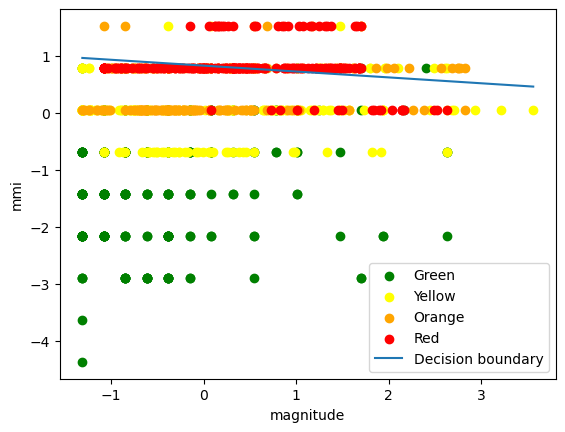

In [36]:
y_bin_X2 = y_change(y_training_X2, 'red')
params_fmin_db = op.fmin_cg(maxiter=400, f=costFunction, x0=initial_theta_X2.flatten(), fprime=gradientFunction,args=(X_training_stan_X2, y_bin_X2.to_numpy().flatten()))
plotDecisionBoundary(X_training_stan_X2, y_training_X2, params_fmin_db , 'magnitude', 'mmi')

#### Inicialización de los parámetros, entrenamiento y cálculo de la tasa de predicción del par de variables magnitude sig

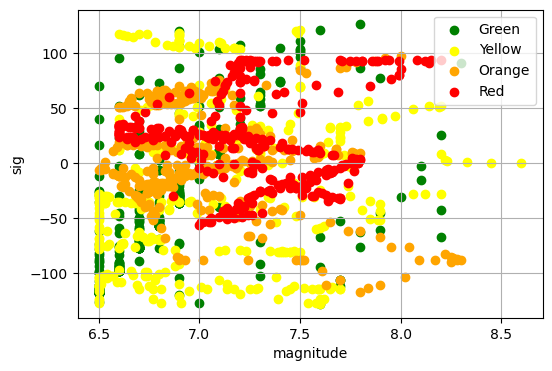

In [37]:
plotData(X, y, 'magnitude', 'sig')

In [38]:
X3 = X[['magnitude','sig']]

#HOLDOUT 70-30
X_training_X3, y_training_X3, X_test_X3, y_test_X3 = holdout(X3, y, 0.7)
#Normalización de los datos de entrenamiento y test antes de añadir la columna de unos para evitar dividir entre 0 y que los valores sean Nan.
X_training_stan_X3, mu_X3, sigma_X3 = featureNormalize(X_training_X3)
X_test_stan_X3 = (X_test_X3 - mu_X3) / sigma_X3

# Se añade una columna de unos al conjunto de entrenamiento y test
X_training_stan_X3.insert(0, 'uno', 1)
X_test_stan_X3.insert(0, 'uno', 1)
initial_theta_X3 = np.zeros((X_training_stan_X3.shape[1],1))
#Ejecución de la función training
res_optimization_training_X3 = training(initial_theta_X3, X_training_stan_X3, y_training_X3, num_classes)
# Calcula la predicción de entrenamiento y la guarda en res_prediction_training_X3
res_prediction_training_X3 = predict(res_optimization_training_X3, X_training_stan_X3)
#Calcula la tasa de acierto comparando la predicción del training con el training real(se mapea para que se comparen valores del mismo tipo)
accuracy_training_X3 = np.mean(res_prediction_training_X3['prediction'] == y_training_X3['alert'].map(mapping))
print("Training accuracy: ", accuracy_training_X3*100)
#Calcula la predicción de test y la guarda res_prediction_test
res_prediction_test_X3 = predict(res_optimization_training_X3, X_test_stan_X3)
#Calcula la tasa de acierto comparando la predicción del test con el test real(se mapea para que se comparen valores del mismo tipo)
accuracy_test_X3 = np.mean(res_prediction_test_X3['prediction'] == y_test_X3['alert'].map(mapping)) 
print("Test accuracy: ", accuracy_test_X3*100)

El tamaño del training debe ser:  910  - Comprobación: tamaño X_training es  910  y tamaño y_training es 910
El tamaño del test debe ser:  390  - Comprobación: tamaño X_test es  390  y tamaño y_test es 390
Optimization terminated successfully.
         Current function value: 0.508346
         Iterations: 9
         Function evaluations: 21
         Gradient evaluations: 21
Optimization terminated successfully.
         Current function value: 0.537342
         Iterations: 9
         Function evaluations: 19
         Gradient evaluations: 19
Optimization terminated successfully.
         Current function value: 0.558395
         Iterations: 8
         Function evaluations: 17
         Gradient evaluations: 17
Optimization terminated successfully.
         Current function value: 0.490338
         Iterations: 7
         Function evaluations: 17
         Gradient evaluations: 17
Training accuracy:  43.2967032967033
Test accuracy:  39.23076923076923


#### Inicialización de los parámetros, entrenamiento y cálculo de la tasa de predicción del par de variables depth cdi

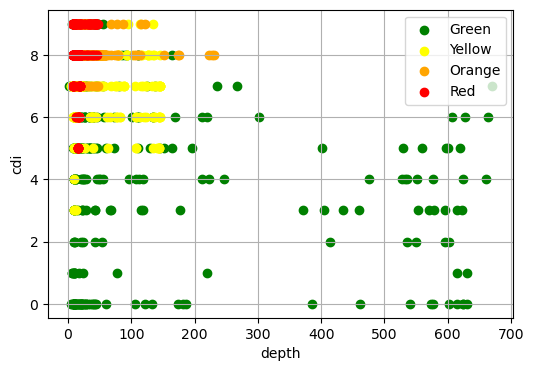

In [39]:
plotData(X, y, 'depth', 'cdi')

In [40]:
X4 = X[['depth','cdi']]

#HOLDOUT 70-30
X_training_X4, y_training_X4, X_test_X4, y_test_X4 = holdout(X4, y, 0.7)
#Normalización de los datos de entrenamiento y test antes de añadir la columna de unos para evitar dividir entre 0 y que los valores sean Nan.
X_training_stan_X4, mu_X4, sigma_X4 = featureNormalize(X_training_X4)
X_test_stan_X4 = (X_test_X4 - mu_X4) / sigma_X4

# Se añade una columna de unos al conjunto de entrenamiento y test
X_training_stan_X4.insert(0, 'uno', 1)
X_test_stan_X4.insert(0, 'uno', 1)
initial_theta_X4 = np.zeros((X_training_stan_X4.shape[1],1))
#Ejecución de la función training
res_optimization_training_X4 = training(initial_theta_X4, X_training_stan_X4, y_training_X4, num_classes)
# Calcula la predicción de entrenamiento y la guarda en res_prediction_training_X4
res_prediction_training_X4 = predict(res_optimization_training_X4, X_training_stan_X4)
#Calcula la tasa de acierto comparando la predicción del training con el training real(se mapea para que se comparen valores del mismo tipo)
accuracy_training_X4 = np.mean(res_prediction_training_X4['prediction'] == y_training_X4['alert'].map(mapping))
print("Training accuracy: ", accuracy_training_X4*100)
#Calcula la predicción de test y la guarda res_prediction_test
res_prediction_test_X4 = predict(res_optimization_training_X4, X_test_stan_X4)
#Calcula la tasa de acierto comparando la predicción del test con el test real(se mapea para que se comparen valores del mismo tipo)
accuracy_test_X4 = np.mean(res_prediction_test_X4['prediction'] == y_test_X4['alert'].map(mapping)) 
print("Test accuracy: ", accuracy_test_X4*100)

El tamaño del training debe ser:  910  - Comprobación: tamaño X_training es  910  y tamaño y_training es 910
El tamaño del test debe ser:  390  - Comprobación: tamaño X_test es  390  y tamaño y_test es 390
Optimization terminated successfully.
         Current function value: 0.335043
         Iterations: 9
         Function evaluations: 27
         Gradient evaluations: 27
Optimization terminated successfully.
         Current function value: 0.547365
         Iterations: 8
         Function evaluations: 20
         Gradient evaluations: 20
Optimization terminated successfully.
         Current function value: 0.513240
         Iterations: 10
         Function evaluations: 27
         Gradient evaluations: 27
Optimization terminated successfully.
         Current function value: 0.428924
         Iterations: 22
         Function evaluations: 69
         Gradient evaluations: 69
Training accuracy:  51.318681318681314
Test accuracy:  48.97435897435897


#### Inicialización de los parámetros, entrenamiento y cálculo de la tasa de predicción del par de variables depth sig

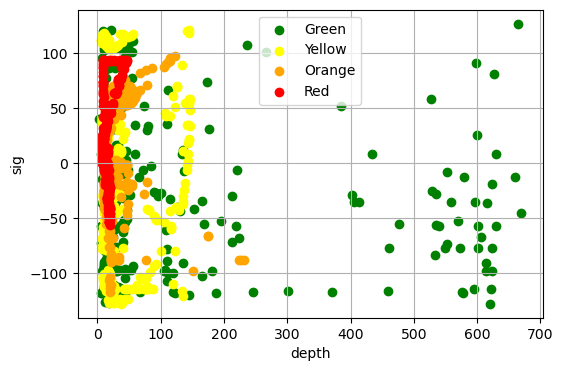

In [41]:
plotData(X, y, 'depth', 'sig')

In [42]:
X5 = X[['depth','sig']]

#HOLDOUT 70-30
X_training_X5, y_training_X5, X_test_X5, y_test_X5 = holdout(X5, y, 0.7)
#Normalización de los datos de entrenamiento y test antes de añadir la columna de unos para evitar dividir entre 0 y que los valores sean Nan.
X_training_stan_X5, mu_X5, sigma_X5 = featureNormalize(X_training_X5)
X_test_stan_X5 = (X_test_X5 - mu_X5) / sigma_X5

# Se añade una columna de unos al conjunto de entrenamiento y test
X_training_stan_X5.insert(0, 'uno', 1)
X_test_stan_X5.insert(0, 'uno', 1)
initial_theta_X5 = np.zeros((X_training_stan_X5.shape[1],1))
#Ejecución de la función training
res_optimization_training_X5 = training(initial_theta_X5, X_training_stan_X5, y_training_X5, num_classes)
# Calcula la predicción de entrenamiento y la guarda en res_prediction_training_X5
res_prediction_training_X5 = predict(res_optimization_training_X5, X_training_stan_X5)
#Calcula la tasa de acierto comparando la predicción del training con el training real(se mapea para que se comparen valores del mismo tipo)
accuracy_training_X5 = np.mean(res_prediction_training_X5['prediction'] == y_training_X5['alert'].map(mapping))
print("Training accuracy: ", accuracy_training_X5*100)
#Calcula la predicción de test y la guarda res_prediction_test
res_prediction_test_X5 = predict(res_optimization_training_X5, X_test_stan_X5)
#Calcula la tasa de acierto comparando la predicción del test con el test real(se mapea para que se comparen valores del mismo tipo)
accuracy_test_X5 = np.mean(res_prediction_test_X5['prediction'] == y_test_X5['alert'].map(mapping)) 
print("Test accuracy: ", accuracy_test_X5*100)

El tamaño del training debe ser:  910  - Comprobación: tamaño X_training es  910  y tamaño y_training es 910
El tamaño del test debe ser:  390  - Comprobación: tamaño X_test es  390  y tamaño y_test es 390
Optimization terminated successfully.
         Current function value: 0.486627
         Iterations: 8
         Function evaluations: 21
         Gradient evaluations: 21
Optimization terminated successfully.
         Current function value: 0.537673
         Iterations: 7
         Function evaluations: 17
         Gradient evaluations: 17
Optimization terminated successfully.
         Current function value: 0.552413
         Iterations: 8
         Function evaluations: 20
         Gradient evaluations: 20
Optimization terminated successfully.
         Current function value: 0.422780
         Iterations: 18
         Function evaluations: 53
         Gradient evaluations: 53
Training accuracy:  44.065934065934066
Test accuracy:  40.256410256410255


#### Inicialización de los parámetros, entrenamiento y cálculo de la tasa de predicción del par de variables mmi sig

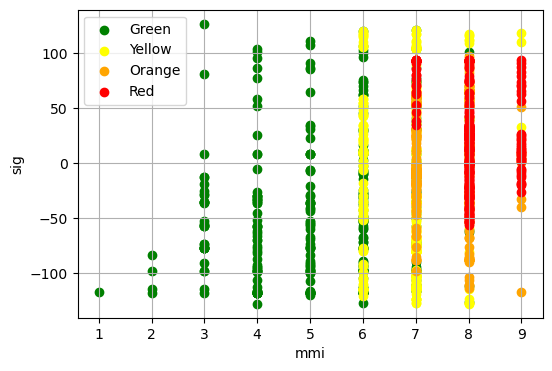

In [43]:
plotData(X, y, 'mmi', 'sig')

In [44]:
X6 = X[['mmi','sig']]

#HOLDOUT 70-30
X_training_X6, y_training_X6, X_test_X6, y_test_X6 = holdout(X6, y, 0.7)
#Normalización de los datos de entrenamiento y test antes de añadir la columna de unos para evitar dividir entre 0 y que los valores sean Nan.
X_training_stan_X6, mu_X6, sigma_X6 = featureNormalize(X_training_X6)
X_test_stan_X6 = (X_test_X6 - mu_X6) / sigma_X6

# Se añade una columna de unos al conjunto de entrenamiento y test
X_training_stan_X6.insert(0, 'uno', 1)
X_test_stan_X6.insert(0, 'uno', 1)
initial_theta_X6 = np.zeros((X_training_stan_X6.shape[1],1))
#Ejecución de la función training
res_optimization_training_X6 = training(initial_theta_X6, X_training_stan_X6, y_training_X6, num_classes)
# Calcula la predicción de entrenamiento y la guarda en res_prediction_training_X6
res_prediction_training_X6 = predict(res_optimization_training_X6, X_training_stan_X6)
#Calcula la tasa de acierto comparando la predicción del training con el training real(se mapea para que se comparen valores del mismo tipo)
accuracy_training_X6 = np.mean(res_prediction_training_X6['prediction'] == y_training_X6['alert'].map(mapping))
print("Training accuracy: ", accuracy_training_X6*100)
#Calcula la predicción de test y la guarda res_prediction_test
res_prediction_test_X6 = predict(res_optimization_training_X6, X_test_stan_X6)
#Calcula la tasa de acierto comparando la predicción del test con el test real(se mapea para que se comparen valores del mismo tipo)
accuracy_test_X6 = np.mean(res_prediction_test_X6['prediction'] == y_test_X6['alert'].map(mapping)) 
print("Test accuracy: ", accuracy_test_X6*100)

El tamaño del training debe ser:  910  - Comprobación: tamaño X_training es  910  y tamaño y_training es 910
El tamaño del test debe ser:  390  - Comprobación: tamaño X_test es  390  y tamaño y_test es 390
Optimization terminated successfully.
         Current function value: 0.263643
         Iterations: 7
         Function evaluations: 22
         Gradient evaluations: 22
Optimization terminated successfully.
         Current function value: 0.538087
         Iterations: 7
         Function evaluations: 17
         Gradient evaluations: 17
Optimization terminated successfully.
         Current function value: 0.524051
         Iterations: 8
         Function evaluations: 20
         Gradient evaluations: 20
Optimization terminated successfully.
         Current function value: 0.347429
         Iterations: 15
         Function evaluations: 42
         Gradient evaluations: 42
Training accuracy:  60.65934065934066
Test accuracy:  55.8974358974359


#### Frontera de decisión de sig y mmi

Optimization terminated successfully.
         Current function value: 0.347429
         Iterations: 15
         Function evaluations: 42
         Gradient evaluations: 42


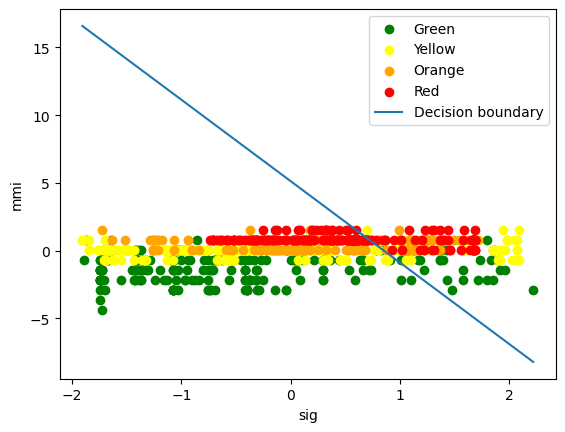

In [45]:
y_bin_X6 = y_change(y_training_X6, 'red')
params_fmin_db_X6 = op.fmin_cg(maxiter=400, f=costFunction, x0=initial_theta_X6.flatten(), fprime=gradientFunction,args=(X_training_stan_X6, y_bin_X6.to_numpy().flatten()))
plotDecisionBoundary(X_training_stan_X6, y_training_X6, params_fmin_db_X6 , 'sig', 'mmi')

#### Análisis de la tasa de aprendizaje para distintos valores de Alpha

In [46]:
def gradientDescent(X, y, theta, alpha, iterations):

    m = len(y) # Numero de instancias en el training
    current_iter = [] # Lista vacía para crear el histórico en un dataframe
    current_cost = [] # Lista vacía para crear el histórico en un dataframe

    for iter in range(iterations):
        h = sigmoid(np.dot(X, theta)) # Hipótesis
        theta = theta - alpha*(1/m)*(np.dot(X.T,(h-y)))

        # Guardar el coste J de cada iteración
        current_iter.append(iter) # Añadir la iteración a una lista
        current_cost.append(costFunction(theta, X, y)) # Añadir el coste a una lista

    J_history = pd.DataFrame({'iteracion': current_iter, 'coste': current_cost}) # Crear el dataframe histórico iteracion-coste

    return theta, J_history # Último theta encontrado y dataframe histórico J_history

#### Recorre cada valor de alpha, calcula el gradiente para cada valor de alpha y lo guarda en la variables theta_final, 
#### de esta manera imprime la gráfica de tasa de aprendizaje para distintos valores de alpha

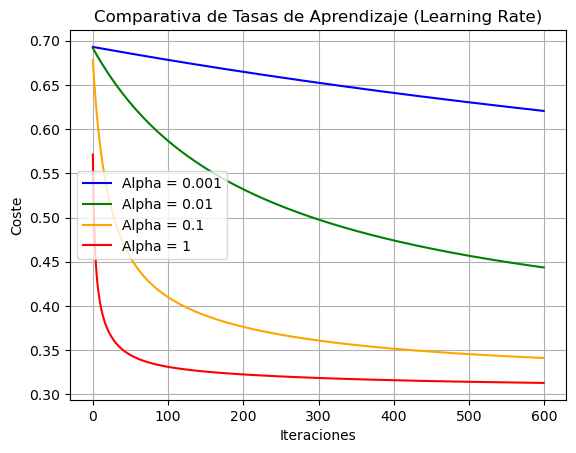

In [47]:
alphas = [0.001, 0.01, 0.1, 1] 
iterations = 600
colores = ['blue', 'green', 'orange', 'red']
theta_final = []

for i, alpha in enumerate(alphas):
    
    theta, history = gradientDescent(X_training_stan, y_bin, initial_theta, alpha, iterations)
    costes = history['coste']
    theta_final.append(theta)
    
    plt.plot(range(len(costes)), costes, label=f'Alpha = {alpha}', color=colores[i])
plt.xlabel('Iteraciones')
plt.ylabel('Coste')
plt.title('Comparativa de Tasas de Aprendizaje (Learning Rate)')
plt.legend()
plt.grid(True)
plt.show()

#### Frontera de decisión para distintos valores de Alpha

Frontera de decisión para Alpha = 0.001


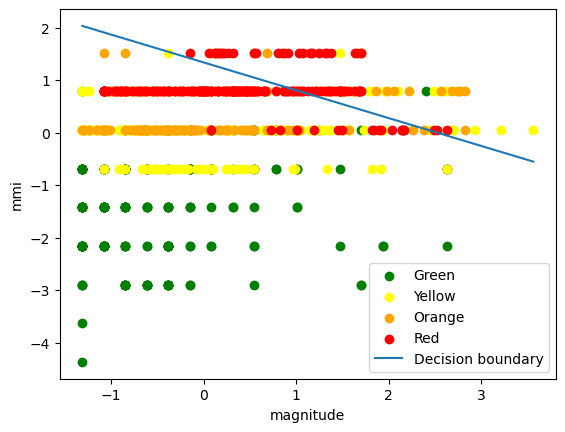

Frontera de decisión para Alpha = 0.01


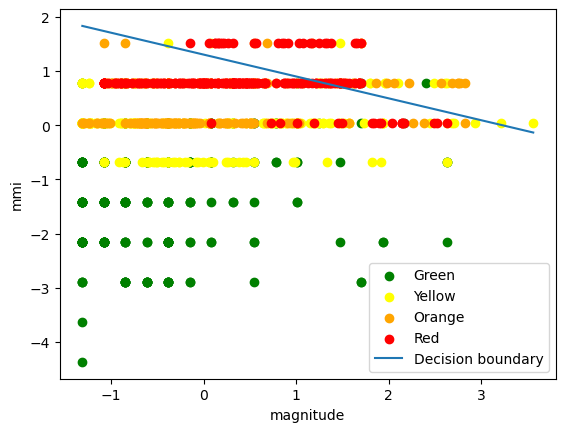

Frontera de decisión para Alpha = 0.1


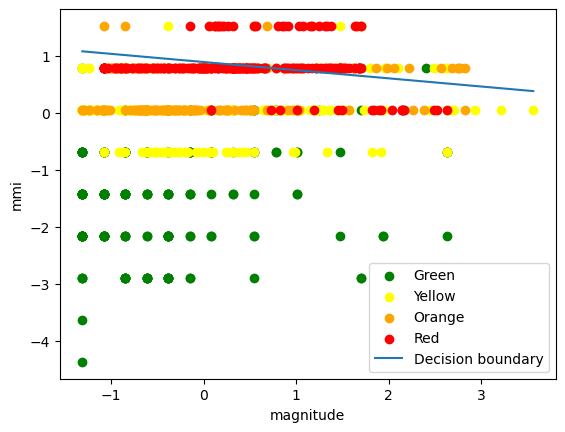

Frontera de decisión para Alpha = 1


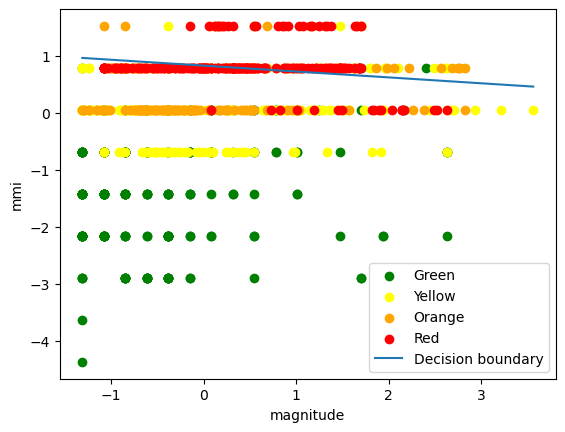

In [48]:
for i, alpha in enumerate(alphas):
    print(f'Frontera de decisión para Alpha = {alpha}')
    theta, history = gradientDescent(X_training_stan_X2, y_bin_X2, initial_theta_X2, alpha, iterations)
    plotDecisionBoundary(X_training_stan_X2, y_training_X2, theta , 'magnitude', 'mmi')    


#### Análisis de los cambios que supone la inicialización de los parámetros (theta)

#### Entrenar el modelo con diferentes estrategias de inicialización


theta = [[0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]]

Optimization terminated successfully.
         Current function value: 0.229612
         Iterations: 12
         Function evaluations: 39
         Gradient evaluations: 39
Optimization terminated successfully.
         Current function value: 0.521335
         Iterations: 14
         Function evaluations: 33
         Gradient evaluations: 33
Optimization terminated successfully.
         Current function value: 0.495559
         Iterations: 15
         Function evaluations: 40
         Gradient evaluations: 40
Optimization terminated successfully.
         Current function value: 0.308496
         Iterations: 51
         Function evaluations: 159
         Gradient evaluations: 159

theta = [[0.01696408]
 [0.06837674]
 [0.09749572]
 [0.08694306]
 [0.04819427]
 [0.05887211]]

Optimization terminated successfully.
         Current function value: 0.229612
         Iterations: 13
         Function evaluations: 40
         Gradient evaluations:

C:\Users\maria\AppData\Local\Temp\ipykernel_18332\1064896327.py:8: RuntimeWarning: divide by zero encountered in log
  J = -(1 / m) * np.sum(np.multiply(y, np.log(h)) + np.multiply(1 - y, np.log(1 - h)), axis=0) #Cálculo del coste vectorizado
C:\Users\maria\AppData\Local\Temp\ipykernel_18332\1064896327.py:8: RuntimeWarning: invalid value encountered in multiply
  J = -(1 / m) * np.sum(np.multiply(y, np.log(h)) + np.multiply(1 - y, np.log(1 - h)), axis=0) #Cálculo del coste vectorizado
C:\Users\maria\AppData\Local\Temp\ipykernel_18332\1064896327.py:8: RuntimeWarning: divide by zero encountered in log
  J = -(1 / m) * np.sum(np.multiply(y, np.log(h)) + np.multiply(1 - y, np.log(1 - h)), axis=0) #Cálculo del coste vectorizado
C:\Users\maria\AppData\Local\Temp\ipykernel_18332\1064896327.py:8: RuntimeWarning: invalid value encountered in multiply
  J = -(1 / m) * np.sum(np.multiply(y, np.log(h)) + np.multiply(1 - y, np.log(1 - h)), axis=0) #Cálculo del coste vectorizado
C:\Users\maria\AppDa

Optimization terminated successfully.
         Current function value: 0.229612
         Iterations: 18
         Function evaluations: 103
         Gradient evaluations: 103
Optimization terminated successfully.
         Current function value: 0.521335
         Iterations: 19
         Function evaluations: 52
         Gradient evaluations: 52
Optimization terminated successfully.
         Current function value: 0.495559
         Iterations: 23
         Function evaluations: 62
         Gradient evaluations: 62
Optimization terminated successfully.
         Current function value: 0.308496
         Iterations: 64
         Function evaluations: 195
         Gradient evaluations: 195


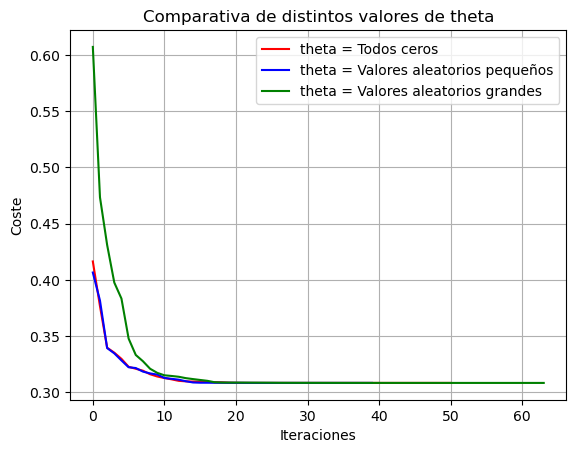

In [49]:
#Distintos valores de theta
initial_theta_0 = np.zeros((X_training_stan.shape[1],1))
initial_theta_1 = np.random.rand(X_training_stan.shape[1],1) * 0.1
initial_theta_2 = np.random.rand(X_training_stan.shape[1],1) * 10

vector_theta = [initial_theta_0, initial_theta_1, initial_theta_2]
# label y colores para el gráfico
label = ["Todos ceros", "Valores aleatorios pequeños", "Valores aleatorios grandes"]
colores = ['red', 'blue', 'green']

#Ejecución de la función training para distintos valores de theta
for i, theta in enumerate(vector_theta):
    print(f'\ntheta = {theta}\n')
    theta_final = training(theta, X_training_stan, y_training, num_classes)
    coste = theta_final['history'][3]
    plt.plot(range(len(coste)), coste, label=f'theta = {label[i]}', color=colores[i])    

plt.xlabel('Iteraciones')
plt.ylabel('Coste')
plt.title('Comparativa de distintos valores de theta')
plt.legend()
plt.grid(True)
plt.show()

#### Análisis de cómo influye el número de iteraciones en el aprendizaje del modelo

In [50]:
#se define la función training2 con el parámetro num_iter para ver como influye el numero de iteraciones en el aprendizaje del modelo
def training2(initial_theta, X_train, y_train, num_clases, num_iter):
  all_theta = [] # Lista vacía para incluir las theta óptimas de cada clase
  all_cost = [] # Lista vacía para incluir el coste final de cada clase
  all_class = [] # Lista vacía para añadir las clases
  all_history = [] #Lista vacía para guardar el coste de cada clase
  alert_list = ['green', 'yellow', 'orange', 'red'] #Lista con el nombre de cada clase
    
  #Bucle for para aplicar el algoritmo de optimización a cada clase
  for current_class in range(num_clases): 
      clase_actual = alert_list[current_class]
      cost_history_class = [] #Lista temporal para el historial de coste esta iteración
      y_bin = y_change(y_train, clase_actual).to_numpy().flatten() # Transforma la clase actual en '1' y el resto en '0'.
      
      res_optimization = op.fmin_cg(maxiter=num_iter, f=costFunction, x0=initial_theta.flatten(), fprime=gradientFunction, 
                             args=(X_train, y_bin),
                             callback = lambda t: costePorClase(t, X_train, y_bin, cost_history_class),
                             full_output = True)

      all_theta.append(res_optimization[0]) # Theta óptimos del algoritmo de optimización
      all_cost.append(res_optimization[1]) # Coste del algoritmo de optimización
      all_class.append(current_class) # Clase actual
      all_history.append(cost_history_class) # Historial de convergencia
    
  df_opt = pd.DataFrame({'class':all_class, 'theta':all_theta, 'cost':all_cost, 'history': all_history}) # Creamos dataframe que devolverá la función
  
  return df_opt

In [51]:
#HOLDOUT 70-30
X_training, y_training, X_test, y_test = holdout(X, y, 0.7)
#Normalización de los datos de entrenamiento y test antes de añadir la columna de unos para evitar dividir entre 0 y que los valores sean Nan.
X_training_stan, mu, sigma = featureNormalize(X_training)
X_test_stan = (X_test - mu) / sigma

# Se añade una columna de unos al conjunto de entrenamiento y test
X_training_stan.insert(0, 'uno', 1)
X_test_stan.insert(0, 'uno', 1)
initial_theta_cero = np.zeros((X_training_stan.shape[1],1))
iteraciones = [5, 10, 30, 50]
errores_test = []  
errores_train = []
#Ejecución de la función training
for i in iteraciones:
    print(f'Entrenamiento del modelo para {i} iteraciones')
    res_opt = training2(initial_theta_cero, X_training_stan, y_training, num_classes, i)
    # Calcula la predicción de entrenamiento y la guarda en res_prediction_training_RL
    res_pred = predict(res_opt, X_training_stan)
    #Calcula la tasa de acierto comparando la predicción del training con el training real(se mapea para que se comparen valores del mismo tipo)
    accuracy_train = np.mean(res_pred['prediction'] == y_training['alert'].map(mapping))
    #Calcula la predicción de test y la guarda res_prediction_test_RL
    res_pred = predict(res_opt, X_test_stan)
    #Calcula la tasa de acierto comparando la predicción del test con el test real(se mapea para que se comparen valores del mismo tipo)
    accuracy_test_RL = np.mean(res_pred['prediction'] == y_test['alert'].map(mapping)) 
    error_test = 1 - accuracy_test_RL
    error_train = 1 - accuracy_train
    errores_train.append(error_train)
    errores_test.append(error_test)    

El tamaño del training debe ser:  910  - Comprobación: tamaño X_training es  910  y tamaño y_training es 910
El tamaño del test debe ser:  390  - Comprobación: tamaño X_test es  390  y tamaño y_test es 390
Entrenamiento del modelo para 5 iteraciones
         Current function value: 0.229754
         Iterations: 5
         Function evaluations: 16
         Gradient evaluations: 16
         Current function value: 0.521383
         Iterations: 5
         Function evaluations: 13
         Gradient evaluations: 13
         Current function value: 0.496174
         Iterations: 5
         Function evaluations: 13
         Gradient evaluations: 13
         Current function value: 0.329885
         Iterations: 5
         Function evaluations: 14
         Gradient evaluations: 14


C:\Users\maria\AppData\Local\Programs\Orange\Lib\site-packages\scipy\optimize\_optimize.py:1659: OptimizeWarning: Maximum number of iterations has been exceeded.
  res = _minimize_cg(f, x0, args, fprime, callback=callback, c1=c1, c2=c2,
C:\Users\maria\AppData\Local\Programs\Orange\Lib\site-packages\scipy\optimize\_optimize.py:1659: OptimizeWarning: Maximum number of iterations has been exceeded.
  res = _minimize_cg(f, x0, args, fprime, callback=callback, c1=c1, c2=c2,
C:\Users\maria\AppData\Local\Programs\Orange\Lib\site-packages\scipy\optimize\_optimize.py:1659: OptimizeWarning: Maximum number of iterations has been exceeded.
  res = _minimize_cg(f, x0, args, fprime, callback=callback, c1=c1, c2=c2,
C:\Users\maria\AppData\Local\Programs\Orange\Lib\site-packages\scipy\optimize\_optimize.py:1659: OptimizeWarning: Maximum number of iterations has been exceeded.
  res = _minimize_cg(f, x0, args, fprime, callback=callback, c1=c1, c2=c2,


Entrenamiento del modelo para 10 iteraciones
         Current function value: 0.229612
         Iterations: 10
         Function evaluations: 32
         Gradient evaluations: 32
         Current function value: 0.521335
         Iterations: 10
         Function evaluations: 24
         Gradient evaluations: 24
         Current function value: 0.495560
         Iterations: 10
         Function evaluations: 27
         Gradient evaluations: 27


C:\Users\maria\AppData\Local\Programs\Orange\Lib\site-packages\scipy\optimize\_optimize.py:1659: OptimizeWarning: Maximum number of iterations has been exceeded.
  res = _minimize_cg(f, x0, args, fprime, callback=callback, c1=c1, c2=c2,
C:\Users\maria\AppData\Local\Programs\Orange\Lib\site-packages\scipy\optimize\_optimize.py:1659: OptimizeWarning: Maximum number of iterations has been exceeded.
  res = _minimize_cg(f, x0, args, fprime, callback=callback, c1=c1, c2=c2,
C:\Users\maria\AppData\Local\Programs\Orange\Lib\site-packages\scipy\optimize\_optimize.py:1659: OptimizeWarning: Maximum number of iterations has been exceeded.
  res = _minimize_cg(f, x0, args, fprime, callback=callback, c1=c1, c2=c2,
C:\Users\maria\AppData\Local\Programs\Orange\Lib\site-packages\scipy\optimize\_optimize.py:1659: OptimizeWarning: Maximum number of iterations has been exceeded.
  res = _minimize_cg(f, x0, args, fprime, callback=callback, c1=c1, c2=c2,


         Current function value: 0.314208
         Iterations: 10
         Function evaluations: 29
         Gradient evaluations: 29
Entrenamiento del modelo para 30 iteraciones
Optimization terminated successfully.
         Current function value: 0.229612
         Iterations: 12
         Function evaluations: 39
         Gradient evaluations: 39
Optimization terminated successfully.
         Current function value: 0.521335
         Iterations: 14
         Function evaluations: 33
         Gradient evaluations: 33
Optimization terminated successfully.
         Current function value: 0.495559
         Iterations: 15
         Function evaluations: 40
         Gradient evaluations: 40


C:\Users\maria\AppData\Local\Programs\Orange\Lib\site-packages\scipy\optimize\_optimize.py:1659: OptimizeWarning: Maximum number of iterations has been exceeded.
  res = _minimize_cg(f, x0, args, fprime, callback=callback, c1=c1, c2=c2,


         Current function value: 0.308502
         Iterations: 30
         Function evaluations: 94
         Gradient evaluations: 94
Entrenamiento del modelo para 50 iteraciones
Optimization terminated successfully.
         Current function value: 0.229612
         Iterations: 12
         Function evaluations: 39
         Gradient evaluations: 39
Optimization terminated successfully.
         Current function value: 0.521335
         Iterations: 14
         Function evaluations: 33
         Gradient evaluations: 33
Optimization terminated successfully.
         Current function value: 0.495559
         Iterations: 15
         Function evaluations: 40
         Gradient evaluations: 40


C:\Users\maria\AppData\Local\Programs\Orange\Lib\site-packages\scipy\optimize\_optimize.py:1659: OptimizeWarning: Maximum number of iterations has been exceeded.
  res = _minimize_cg(f, x0, args, fprime, callback=callback, c1=c1, c2=c2,


         Current function value: 0.308496
         Iterations: 50
         Function evaluations: 156
         Gradient evaluations: 156


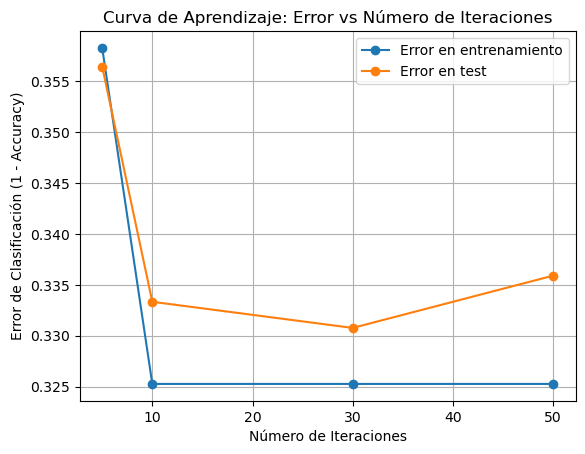

In [52]:
plt.plot(iteraciones, errores_train, marker='o', label='Error en entrenamiento')
plt.plot(iteraciones, errores_test, marker='o', label='Error en test')

plt.title('Curva de Aprendizaje: Error vs Número de Iteraciones')
plt.xlabel('Número de Iteraciones')
plt.ylabel('Error de Clasificación (1 - Accuracy)')
plt.legend()
plt.grid(True)
plt.show()

#### Experimentar con modelos cuadráticos

In [53]:
#Se crea una variable X_cuad con los valores de X y las tres columnas para el modelo cuadrático
var1 = 'magnitude'
var2 = 'mmi'
X_cuad = X[[var1, var2]].copy()
X_cuad[f'{var1}2'] = X_cuad[var1] ** 2
X_cuad[f'{var2}2'] = X_cuad[var2] ** 2
X_cuad['interaction'] = X_cuad[var1] * X_cuad[var2]


#HOLDOUT 70-30
X_training, y_training, X_test, y_test = holdout(X_cuad, y, 0.7)
#Normalización de los datos de entrenamiento y test antes de añadir la columna de unos para evitar dividir entre 0 y que los valores sean Nan.
X_training_stan, mu, sigma = featureNormalize(X_training)
X_test_stan = (X_test - mu) / sigma

# Se añade una columna de unos al conjunto de entrenamiento y test
X_training_stan.insert(0, 'uno', 1)
X_test_stan.insert(0, 'uno', 1)

initial_theta = np.zeros((X_training_stan.shape[1],1))
#Ejecución de la función training
res_optimization_training = training(initial_theta, X_training_stan, y_training, num_classes)

# Calcula la predicción de entrenamiento y la guarda en res_prediction_training
res_prediction_training = predict(res_optimization_training, X_training_stan)

accuracy_training = np.mean(res_prediction_training['prediction'] == y_training['alert'].map(mapping))
print("Training accuracy: ", accuracy_training)

#Calcula la predicción de test y la guarda res_prediction_test
res_prediction_test = predict(res_optimization_training, X_test_stan)
#Calcula la tasa de acierto comparando la predicción del test con el test real(se mapea para que se comparen valores del mismo tipo)
accuracy_test = np.mean(res_prediction_test['prediction'] == y_test['alert'].map(mapping)) 
print("Test accuracy: ", accuracy_test)

El tamaño del training debe ser:  910  - Comprobación: tamaño X_training es  910  y tamaño y_training es 910
El tamaño del test debe ser:  390  - Comprobación: tamaño X_test es  390  y tamaño y_test es 390
Optimization terminated successfully.
         Current function value: 0.254106
         Iterations: 40
         Function evaluations: 128
         Gradient evaluations: 128
Optimization terminated successfully.
         Current function value: 0.448997
         Iterations: 64
         Function evaluations: 172
         Gradient evaluations: 172
Optimization terminated successfully.
         Current function value: 0.480899
         Iterations: 61
         Function evaluations: 170
         Gradient evaluations: 170
Optimization terminated successfully.
         Current function value: 0.308877
         Iterations: 172
         Function evaluations: 507
         Gradient evaluations: 507
Training accuracy:  0.5857142857142857
Test accuracy:  0.6


In [54]:
#Imrpime la frontera de decisión cuadrática
def plotQuadraticBoundary(X, y, theta, label_x, label_y):

    green = X[y['alert'] == 'green']
    yellow = X[y['alert'] == 'yellow']
    orange = X[y['alert'] == 'orange']
    red = X[y['alert'] == 'red']

    plt.scatter(green[label_x], green[label_y], c='green', label='Green')
    plt.scatter(yellow[label_x], yellow[label_y], c='yellow', label='Yellow')
    plt.scatter(orange[label_x], orange[label_y], c='orange', label='Orange')
    plt.scatter(red[label_x], red[label_y], c='red', label='Red')

    u = np.linspace(X[label_x].min(), X[label_x].max(), 100)
    v = np.linspace(X[label_y].min(), X[label_y].max(), 100)
    z = np.zeros((len(u), len(v)))

    theta = theta.flatten() # Asegurar que es un vector plano

    # 3. CALCULAR EL VALOR Z PARA CADA PUNTO
    #Se aplica la fórmula cuadrática completa:
    # z = th0 + th1*x + th2*y + th3*x^2 + th4*y^2 + th5*x*y
    for i in range(len(u)):
        for j in range(len(v)):
            val_x = u[i]
            val_y = v[j]
            features = np.array([1,val_x, val_y, val_x**2, val_y**2, val_x*val_y])
            z[i,j] = np.dot(features, theta)

    # 4. PINTAR LA LÍNEA DONDE z = 0 (La frontera)
    # plt.contour dibuja la curva
    plt.contour(u, v, z.T, [0], colors='blue', linewidths=2)
    
    plt.xlabel(label_x)
    plt.ylabel(label_y)
    plt.title('Frontera de Decisión Cuadrática')
    plt.legend()
    plt.grid(True)
    plt.show()

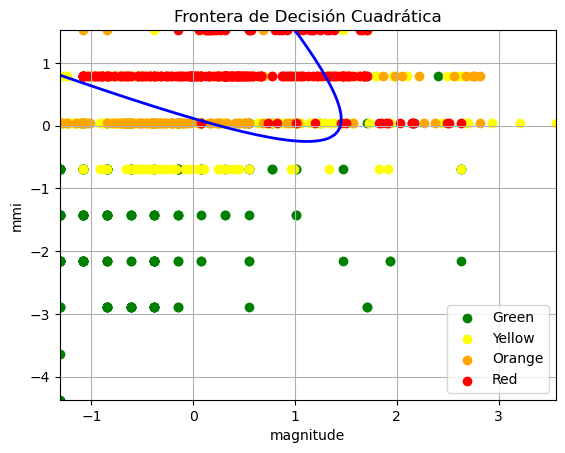

In [55]:
plotQuadraticBoundary(X_training_stan, y_training_X2, res_optimization_training['theta'][3] , 'magnitude', 'mmi')